## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [44]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,Missing values
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


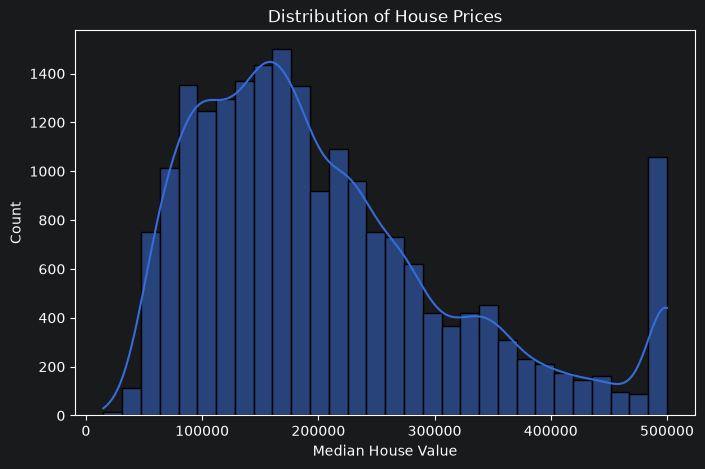

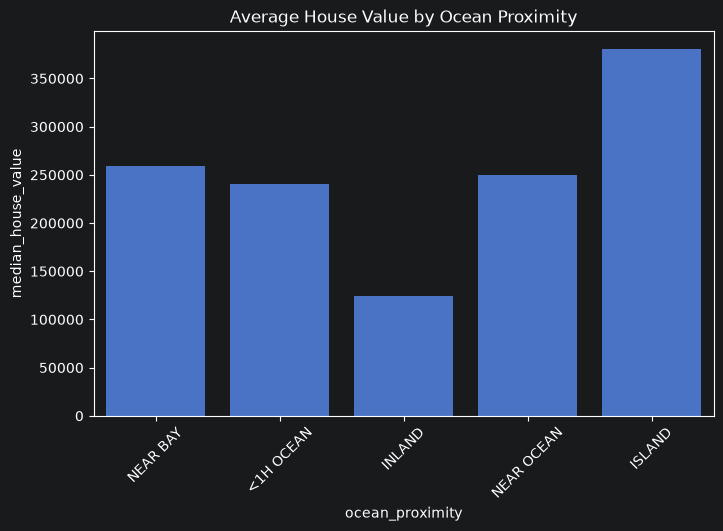

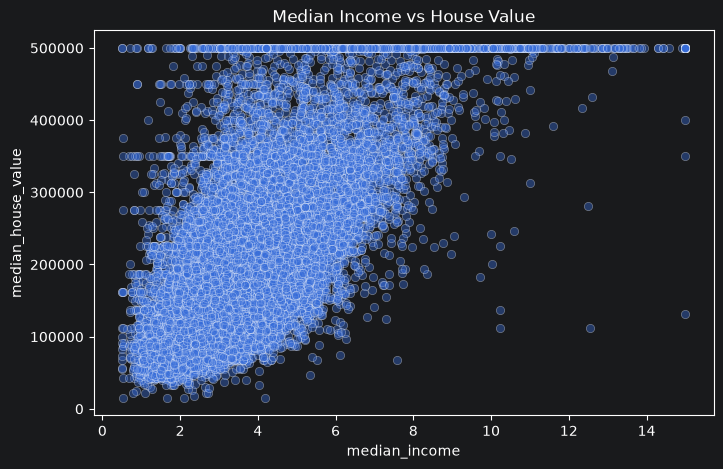

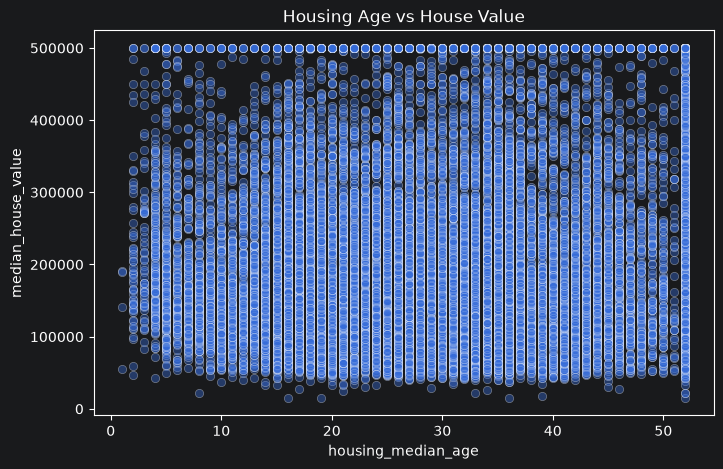

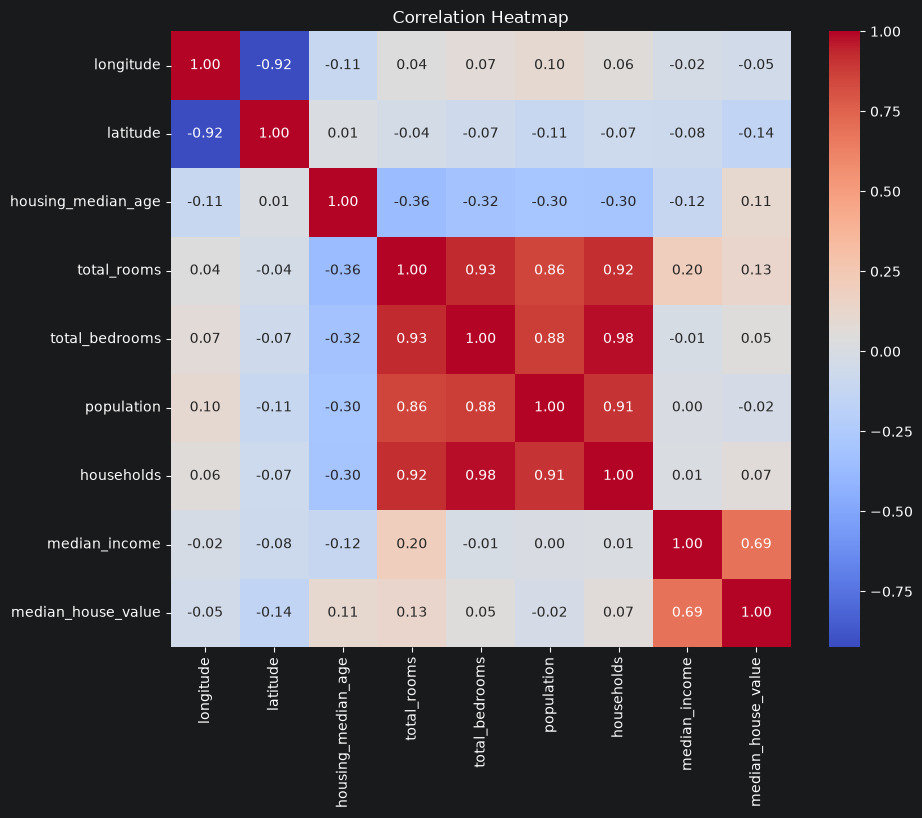

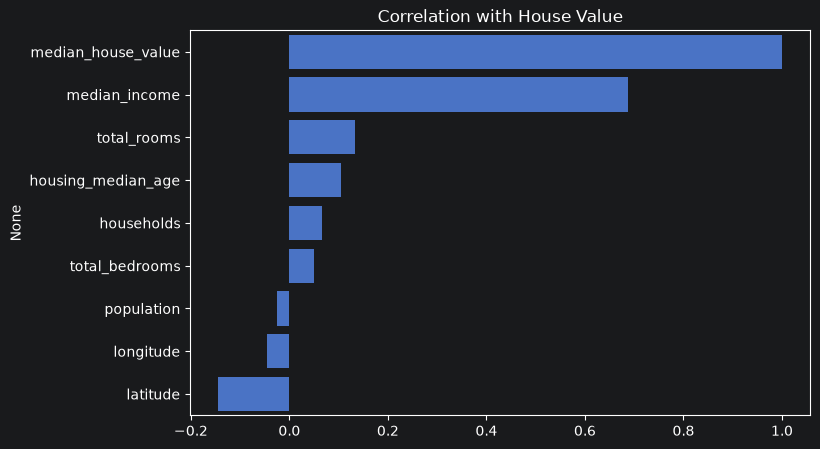

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns


display(df.head())
display(df.describe())
display(df.isnull().sum().to_frame("Missing values"))

#Distribution of house prices

plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

#average house value by ocean proximity

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average House Value by Ocean Proximity")
plt.show()

#Median income vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.4
)

plt.title("Median Income vs House Value")
plt.show()

# Housing age vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.4
)

plt.title("Housing Age vs House Value")
plt.show()

#Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr = numeric_df.corr()["median_house_value"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)

plt.title("Correlation with House Value")
plt.show()

10 conclusions from the above analysis:
1. The distribution of house prices is right-skewed, indicating that there are a few very high-priced houses in the dataset.
2. There are 207 missing values in the "total_bedrooms" column, which may need to be addressed before modeling.
3. The average house value varies significantly based on ocean proximity, with houses closer to the ocean generally having higher values, while houses further inland tend to have lower values (in land).
4. There is a clear positive relationship between median income and median house value. As the median income increases, the median house value generally increases as well.
5. There is no clear linear relationship between housing median age and median house value. Houses with similar ages can have very different prices.
6. The strongest positive correlations are between:
- total rooms and total bedrooms (0.93)
- total rooms and population (0.86)
- total rooms and households (0.92)
- total bedrooms and population (0.88)
- total bedrooms and households (0.98)
- population and households (0.91)
- median income and median house value (0.69)
7. The strongest negative correlation is between longitude and latitude (-0.92).
8. Moderate negative correlations exist between median house value and both longitude (-0.05) and latitude (-0.14), suggesting that location may play a role in house pricing; house_median_age with: total_bedroom, total_rooms, households and population.
9. Moderate positive correlations exist between housing_median_age and median_house_value, total_rooms and median_income, total rooms and median_house_value.
10. Overall, the analysis suggests that factors such as ocean proximity, median income, and certain housing characteristics (like total rooms and total bedrooms) are important predictors of house value.

The most significant feature that correlates with house price is median_income.

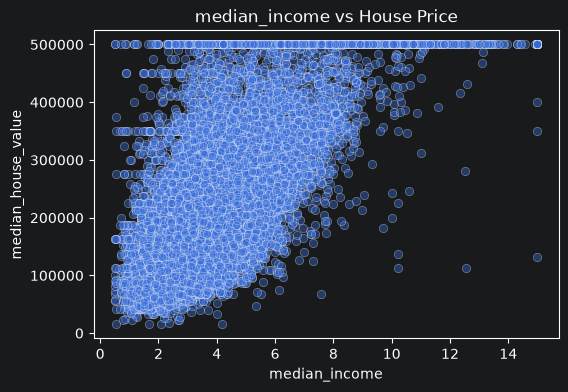

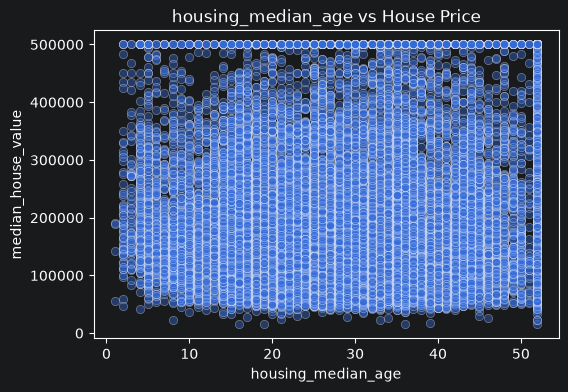

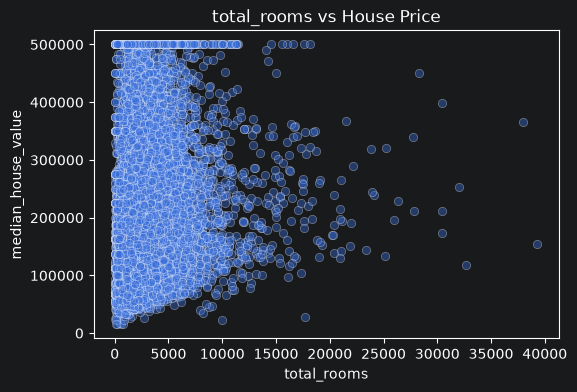

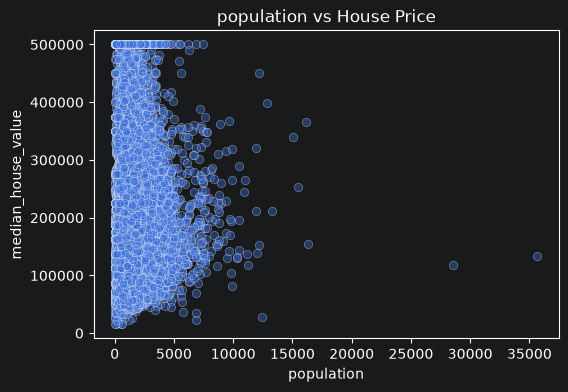

In [46]:
important_features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

for feature in important_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[feature],
        y=df["median_house_value"],
        alpha=0.4
    )

    plt.title(f"{feature} vs House Price")

    plt.show()

scatter plots for every important feature.
the most significant feature correlated with house price is median_income, which is actually not surprising since income is a key factor in determining the affordability of housing.

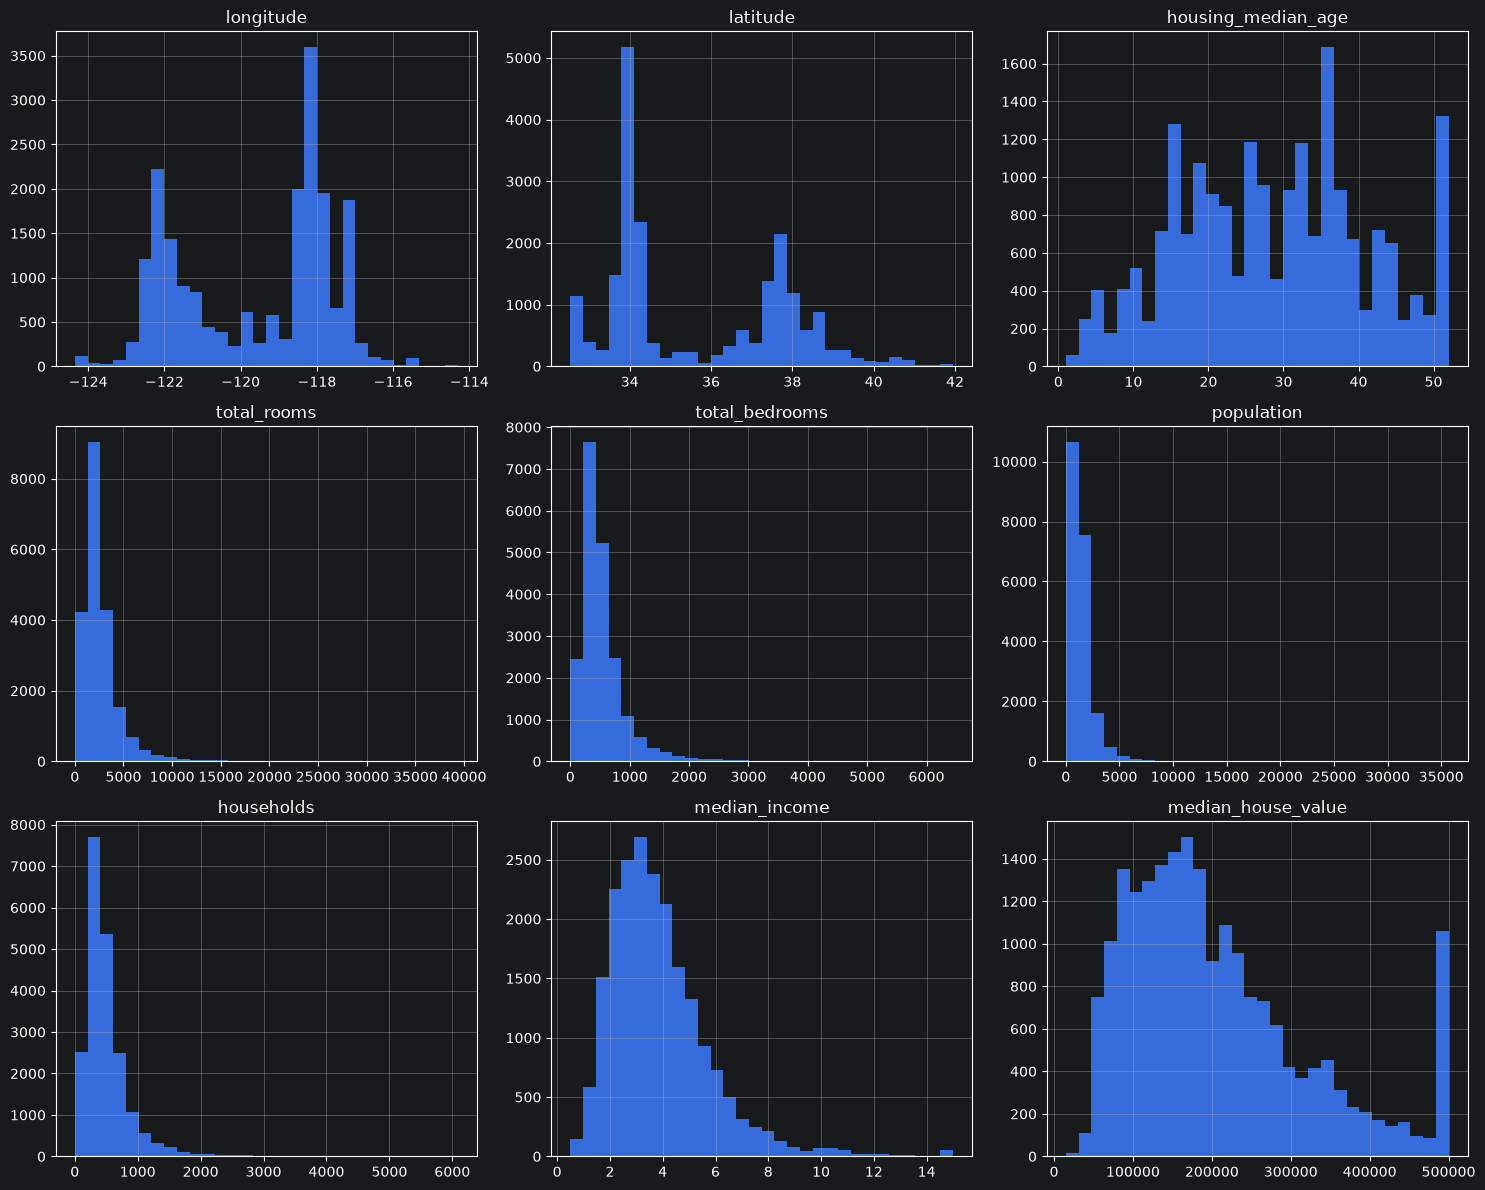

In [47]:
df.hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()

plt.show()

ML Pipeline for house pricing
--------------------------------------------------------------------------

In [48]:
#incarcarea datelor
import pandas as pd

df = pd.read_csv("dataset/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [49]:
#elimiare outlineri
Q1 = df["median_house_value"].quantile(0.25)
Q3 = df["median_house_value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["median_house_value"] >= lower) &
    (df["median_house_value"] <= upper)
]

In [50]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [51]:
##split the cleaned dataset into training and testing sets
from sklearn.model_selection import train_test_split

# 80% pentru antrenarea modelului
# 20% pentru testarea finala

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15655, 9)
X_test: (3914, 9)
y_train: (15655,)
y_test: (3914,)


In [52]:
#facem mediana DOAR din X_train
median_total_bedrooms = X_train["total_bedrooms"].median()

#apoi aplicam mediana pe X_train
X_train["total_bedrooms"] = X_train["total_bedrooms"].fillna(
    median_total_bedrooms
)

#si evident aplicam aceeasi mediana pe X_test
X_test["total_bedrooms"] = X_test["total_bedrooms"].fillna(
    median_total_bedrooms
)

In [53]:
#verificare pt ca am avut o eroare la ocean proximity inainte
print("Missing values X_train:")
print(X_train.isnull().sum())

print("\nMissing values X_test:")
print(X_test.isnull().sum())

Missing values X_train:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

Missing values X_test:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64


In [54]:
#transformare coloana categorica ocean_proximity in coloane numerice de 0/1
X_train = pd.get_dummies(
    X_train,
    columns=["ocean_proximity"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["ocean_proximity"],
    drop_first=True
)

#asigurare ca train si test au aceeasi coloana
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [55]:
#scurta verificare
print(X_train.dtypes)

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
ocean_proximity_INLAND           bool
ocean_proximity_ISLAND           bool
ocean_proximity_NEAR BAY         bool
ocean_proximity_NEAR OCEAN       bool
dtype: object


In [56]:
#verificare finala
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

print("\nMissing values X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values X_test:")
print(X_test.isnull().sum().sum())

print("\nColoane non-numerice:")
print(X_train.select_dtypes(include=["object"]).columns)

Shape X_train: (15655, 12)
Shape X_test: (3914, 12)

Missing values X_train:
0

Missing values X_test:
0

Coloane non-numerice:
Index([], dtype='str')


In [57]:
#linear regression with evaluation (mae, rmse, r2)
# Linear Regression - Train vs Test Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)

rmse_lr_train = np.sqrt(
    mean_squared_error(y_train, y_pred_lr_train)
)

r2_lr_train = r2_score(
    y_train, y_pred_lr_train
)


mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)

rmse_lr_test = np.sqrt(
    mean_squared_error(y_test, y_pred_lr_test)
)

r2_lr_test = r2_score(
    y_test, y_pred_lr_test
)


print("Linear Regression")

print("\nTrain Metrics:")
print(f"Train MAE: {mae_lr_train:.2f}")
print(f"Train RMSE: {rmse_lr_train:.2f}")
print(f"Train R2: {r2_lr_train:.3f}")

print("\nTest Metrics:")
print(f"Test MAE: {mae_lr_test:.2f}")
print(f"Test RMSE: {rmse_lr_test:.2f}")
print(f"Test R2: {r2_lr_test:.3f}")

Linear Regression

Train Metrics:
Train MAE: 43790.39
Train RMSE: 59257.61
Train R2: 0.613

Test Metrics:
Test MAE: 43498.44
Test RMSE: 59003.11
Test R2: 0.624


The model was also evaluated using only numerical features. Performance remained similar, indicating that numerical attributes capture most of the predictive information.

In [58]:
#random forest cu evaluare
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.3f}")

Random Forest
MAE: 29219.46
RMSE: 43218.62
R2: 0.798


In [59]:
#polynomial regression of degree 2

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

#degree=2 inseamna ca modelul va folosi si interactiuni si termeni la puterea a doua
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

#trianing model just on training data
poly_model.fit(X_train, y_train)

#predictions on train and test
y_pred_poly_train = poly_model.predict(X_train)
y_pred_poly_test = poly_model.predict(X_test)



#TRAIN matrics
mae_poly_train = mean_absolute_error(y_train, y_pred_poly_train)
rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_pred_poly_train))
r2_poly_train = r2_score(y_train, y_pred_poly_train)

#TEST matrcis
mae_poly_test = mean_absolute_error(y_test, y_pred_poly_test)
rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_pred_poly_test))
r2_poly_test = r2_score(y_test, y_pred_poly_test)

print("Polynomial Regression (Degree 2)")
print(f"Train MAE: {mae_poly_train:.2f}")
print(f"Train RMSE: {rmse_poly_train:.2f}")
print(f"Train R2: {r2_poly_train:.3f}")

print()

print(f"Test MAE: {mae_poly_test:.2f}")
print(f"Test RMSE: {rmse_poly_test:.2f}")
print(f"Test R2: {r2_poly_test:.3f}")

Polynomial Regression (Degree 2)
Train MAE: 41827.10
Train RMSE: 56625.34
Train R2: 0.647

Test MAE: 41631.66
Test RMSE: 66573.90
Test R2: 0.521


In [60]:
#gradient boosting cu evaluare
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R2: {r2_gb:.3f}")

Gradient Boosting
MAE: 35098.32
RMSE: 49102.57
R2: 0.739


In [61]:
#cross validation
from sklearn.model_selection import cross_val_score

#5-Fold Cross Validation pe Random Forest
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("R2 pentru fiecare fold:")
print(cv_scores)

print("\nR2 mediu:")
print(np.mean(cv_scores))

print("\nDeviatia standard:")
print(np.std(cv_scores))

R2 pentru fiecare fold:
[0.78909294 0.78301917 0.77918631 0.76614765 0.78931208]

R2 mediu:
0.7813516294007102

Deviatia standard:
0.008507959718973232


In [62]:
#grid search
from sklearn.model_selection import GridSearchCV

#definim hiperparametrii pe care vrem sa ii testam
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

#cu grid search testam toate combinatiile folosind 5 fold uri cross validation

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

#cautarea o facem NUMAI pe training data
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R2:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation R2:
0.7813516294007102


In [63]:
#train final model with best found parameters
#luam modelul Random Forest cu cei mai buni hiperparametri
best_rf = grid_search.best_estimator_

#modelul final este antrenat pe intregul X_train
best_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [64]:
#evaluare on test data
#faacem predictiile finale pe datele pe care modelul nu le-a folosit nici la antrenare, nici la Grid Search

y_pred = best_rf.predict(X_test)

#calc metricile
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Random Forest Model")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

Final Random Forest Model
MAE: 29219.46
RMSE: 43218.62
R2: 0.798


* mae - mean absolute error between predicted value and real value = 31494 dollars (approx)
* rmse - more sensitive to outliners = 48850 dollars (approx)
* r2 - the model has 81,8% accuracy, which is close to 1, so it is a pretty god model

In [65]:
#linear vs polynomial

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression (Degree 2)"
    ],

    "Train R2": [
        r2_lr_train,
        r2_poly_train
    ],

    "Test R2": [
        r2_lr_test,
        r2_poly_test
    ],

    "Train MAE": [
        mae_lr_train,
        mae_poly_train
    ],

    "Test MAE": [
        mae_lr_test,
        mae_poly_test
    ],

    "Train RMSE": [
        rmse_lr_train,
        rmse_poly_train
    ],

    "Test RMSE": [
        rmse_lr_test,
        rmse_poly_test
    ]
})

comparison = comparison.round({
    "Train R2": 3,
    "Test R2": 3,
    "Train MAE": 2,
    "Test MAE": 2,
    "Train RMSE": 2,
    "Test RMSE": 2
})

print("Regression Models Performance Summary")
comparison

Regression Models Performance Summary


,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.613,0.624,43790.39,43498.44,59257.61,59003.11
1,Polynomial Regression (Degree 2),0.647,0.521,41827.10,41631.66,56625.34,66573.90


In [66]:
#compare Train vs Test R2 to check for possible overfitting

comparison["R2 Gap"] = (
    comparison["Train R2"] - comparison["Test R2"]
)

print("Overfitting Analysis")

comparison[["Model", "Train R2", "Test R2", "R2 Gap"]]

Overfitting Analysis


,Model,Train R2,Test R2,R2 Gap
0,Linear Regression,0.613,0.624,-0.011
1,Polynomial Regression (Degree 2),0.647,0.521,0.126


- Linear Regression → practic nu are overfitting (train si test sunt aproape identice, chiar testul este foarte putin mai mare din cauza impartirii aleatoare).

- Polynomial Regression → are mild overfitting, deoarece performanta pe train este sensibil mai buna decat pe test.

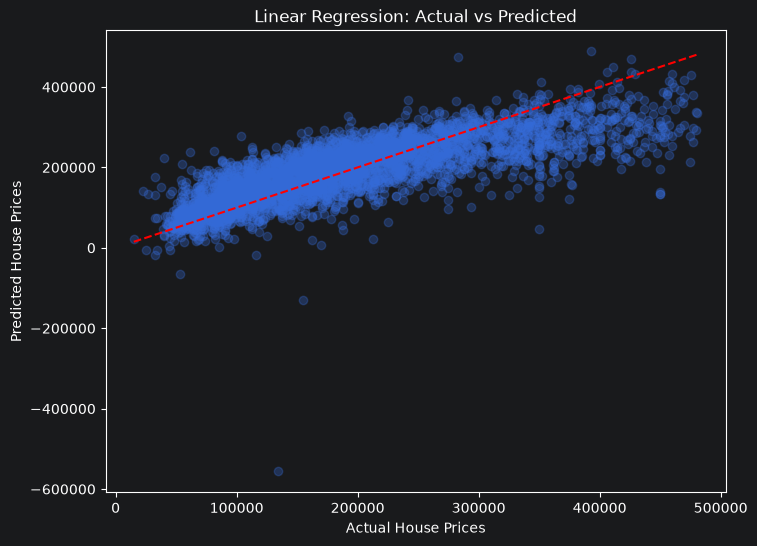

In [67]:
#actual vs predicted linear regression
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lr_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

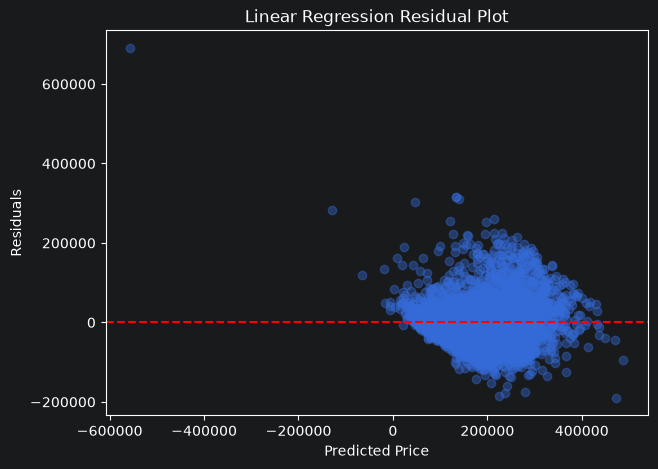

In [68]:
#residual plot
residuals = y_test - y_pred_lr_test

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred_lr_test,
    residuals,
    alpha=0.4
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Linear Regression Residual Plot")

plt.show()

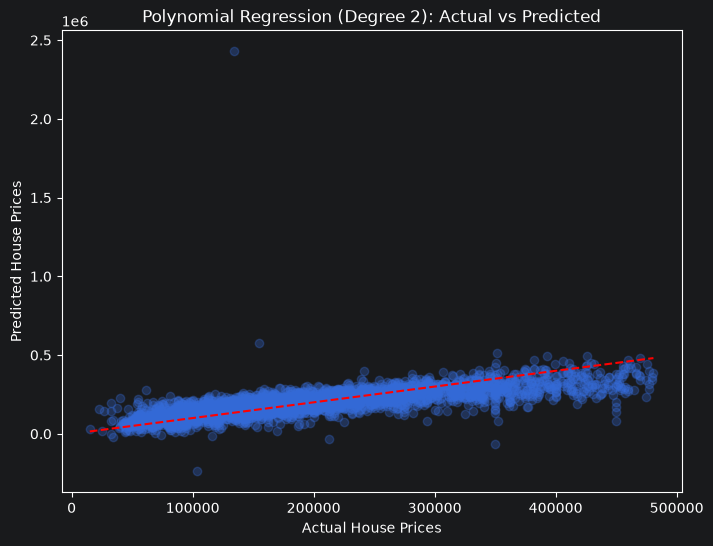

In [69]:
#actual vs predicted polynomial regression
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_poly_test,
    alpha=0.3
)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Polynomial Regression (Degree 2): Actual vs Predicted")

plt.show()

In the Linear Regression plot, most predictions follow the ideal diagonal line, indicating a consistent relationship between the actual and predicted house prices. The prediction errors remain relatively stable across the dataset.

In contrast, the Polynomial Regression plot contains several extreme predictions that are far from the ideal line. These outliers increase the prediction error and suggest that the polynomial model is less stable. Overall, the Linear Regression model produces predictions that are closer to the true values and demonstrates better generalization.

The Linear Regression model achieved better generalization than the Polynomial Regression (Degree 2). Although the polynomial model obtained a slightly higher training R2 (0.647 vs. 0.613), its test R2 dropped to 0.521, while the linear model reached 0.624 on the test set. The R2 gap of 0.126 for the polynomial model also indicates mild overfitting, whereas the linear model shows almost no overfitting (R2 gap = -0.011). Therefore, Linear Regression provides more reliable predictions on unseen data.

In [72]:
#compare all regression models

all_models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression (Degree 2)",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Test R2": [
        r2_lr_test,
        r2_poly_test,
        r2_rf,
        r2_gb
    ],

    "Test MAE": [
        mae_lr_test,
        mae_poly_test,
        mae_rf,
        mae_gb
    ],

    "Test RMSE": [
        rmse_lr_test,
        rmse_poly_test,
        rmse_rf,
        rmse_gb
    ]
})

all_models = all_models.sort_values(
    by="Test R2",
    ascending=False
).round(3)

print("Model Comparison")
all_models

Model Comparison


,Model,Test R2,Test MAE,Test RMSE
2,Random Forest,0.798,29219.461,43218.619
3,Gradient Boosting,0.739,35098.321,49102.566
0,Linear Regression,0.624,43498.441,59003.107
1,Polynomial Regression (Degree 2),0.521,41631.658,66573.900


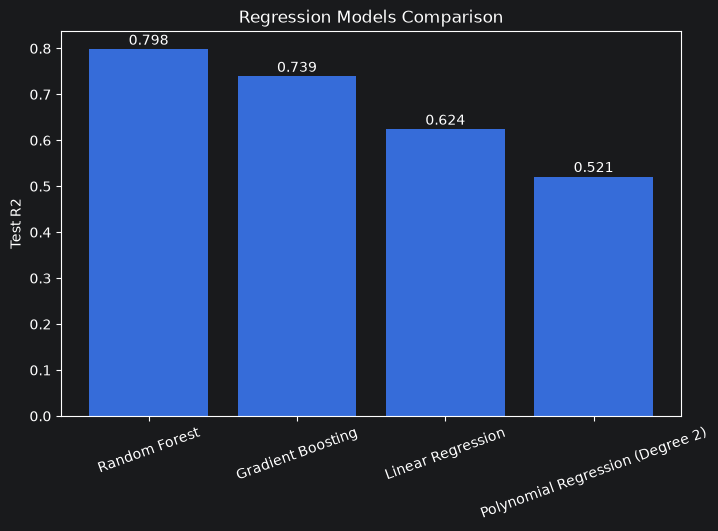

In [75]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    all_models["Model"],
    all_models["Test R2"]
)

plt.title("Regression Models Comparison")
plt.ylabel("Test R2")
plt.xticks(rotation=20)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.show()

The comparison shows that Random Forest achieved the best overall performance, obtaining the highest R2 score (0.798) and the lowest prediction errors (MAE = 29,219.46, RMSE = 43,218.62). This indicates that it explains the largest proportion of the variance in house prices while producing the most accurate predictions.

Gradient Boosting ranked second with a Test R2 of 0.739. Although its performance was slightly lower than Random Forest, it still outperformed both Linear Regression and Polynomial Regression.

Linear Regression provided stable and interpretable results, achieving a Test R2 of 0.624. While its predictive performance was lower than the ensemble methods, it generalized well without signs of overfitting.

Polynomial Regression (Degree 2) performed the worst on the test set, with a Test R2 of 0.521. Despite achieving lower MAE than Linear Regression, its lower R2 and higher RMSE indicate that it was less effective at explaining the variability in the data. The previous train-test comparison also suggested mild overfitting.

Overall, Random Forest is the best-performing model for this dataset and is the recommended choice for predicting house prices.

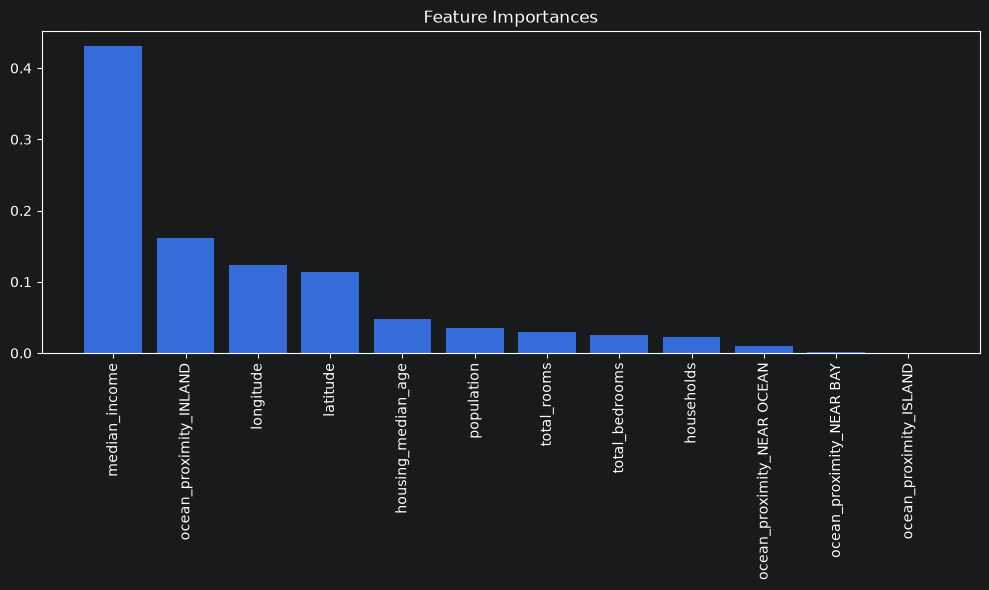

In [70]:
#feature importance
#extragem importanta pt fiecare feature
importances = best_rf.feature_importances_

#sortam feat urile dupa importanta descrescator
indices = np.argsort(importances)[::-1]

features = X_train.columns

plt.figure(figsize=(10,6))

plt.title("Feature Importances")

plt.bar(
    range(len(importances)),
    importances[indices]
)

plt.xticks(
    range(len(importances)),
    features[indices],
    rotation=90
)

plt.tight_layout()

plt.show()

The most important feature in predicting house prices is median_income, it was actually derived from the above analysis.

Possible improvments:
- testing another algorithms (xgboost etc)
- creating new features
- better treating of outliners
- additional adjustment of the parameters

In [73]:
#deployment: we save the model into a .pkl file for further predictions on new data, optional btw
#import joblib

#joblib.dump(best_rf, "house_price_model.pkl")